# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor, as_completed
import os

plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

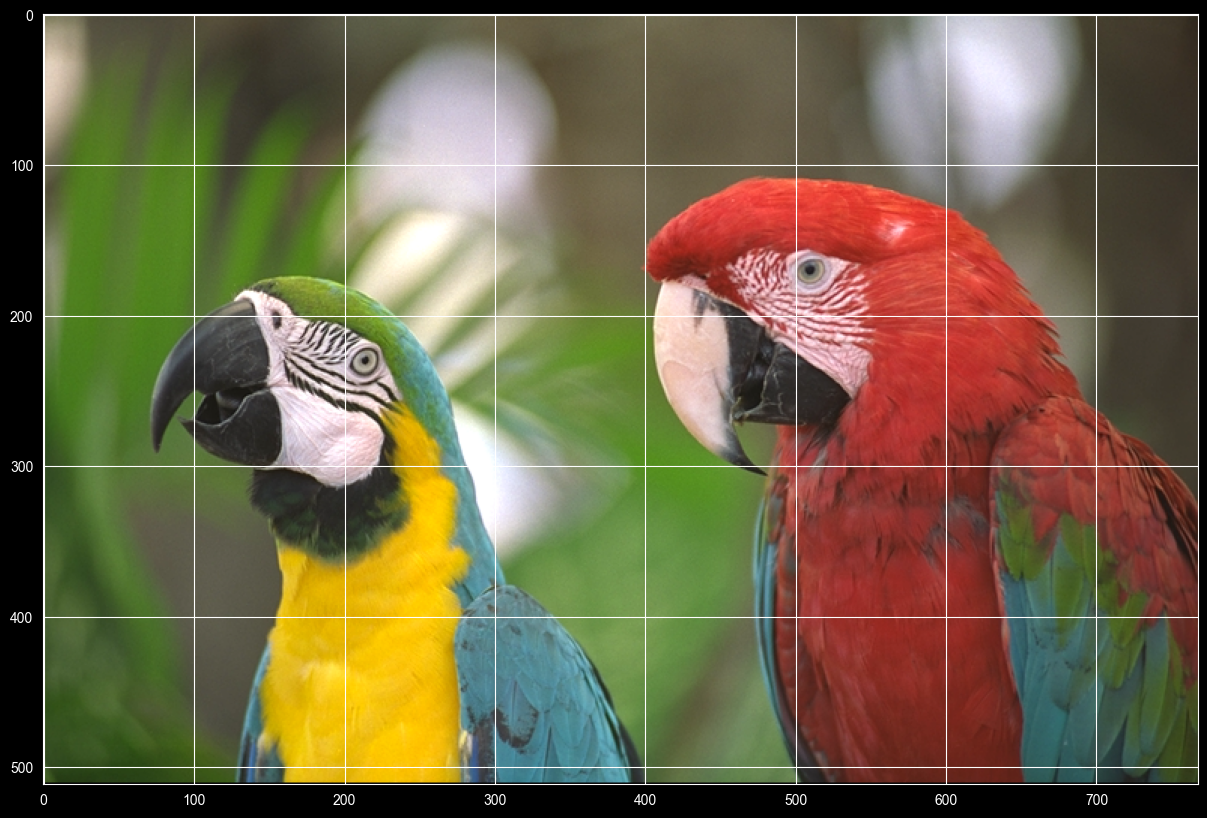

In [14]:
# Load image
img = cv2.imread('../data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_orig = img.copy()

# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [10]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [11]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c, :]
        
        # Find the closest color from the palette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        # new_pixel =  np.sqrt(np.sum((colors - pixel) ** 2, axis=1)).argmin()

        # Absolute value distance
        new_pixel = np.abs(colors - pixel).sum(axis=1).argmin()
        
        # Apply quantization
        quantized[r, c, :] = colors[new_pixel]

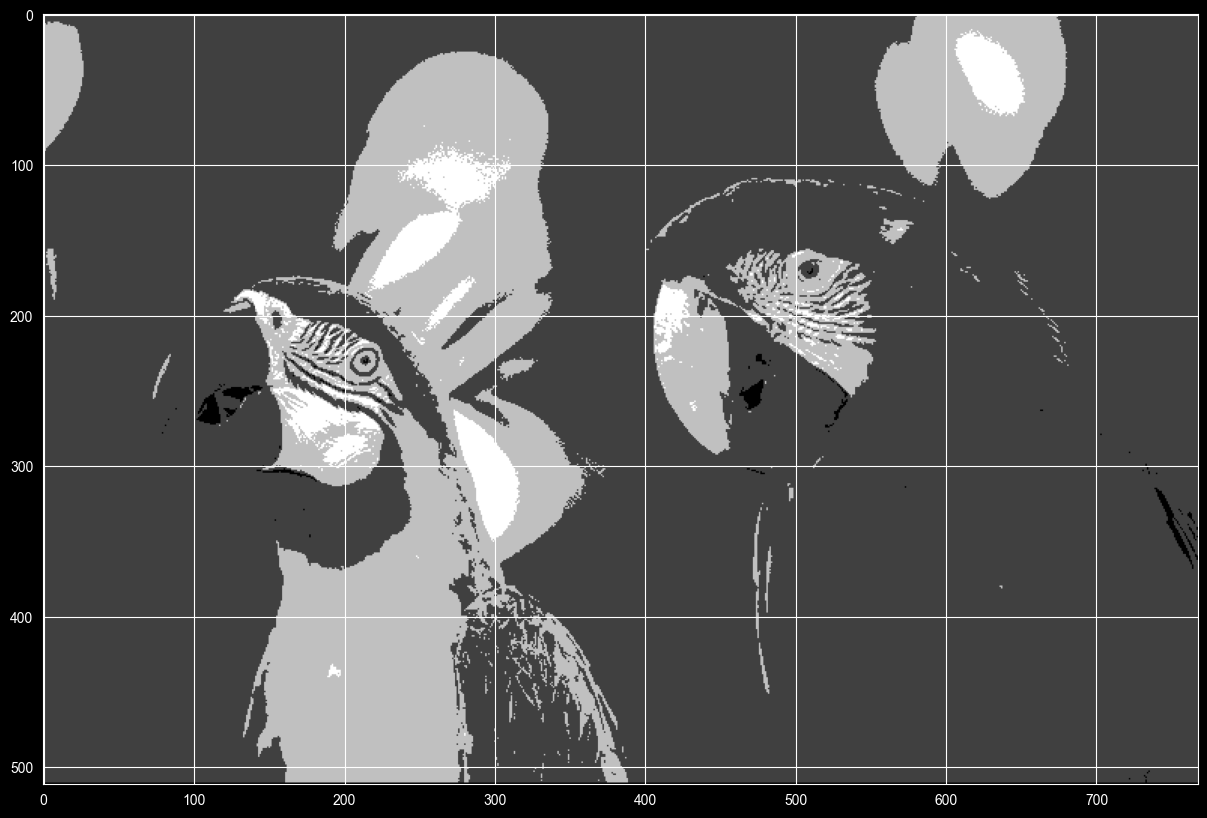

In [12]:
# Show quantized image (don't forget to cast back to uint8)
quantized = np.clip(quantized, 0, 255).astype(np.uint8)

plt.imshow(quantized)

In [13]:
# Compute average quantization error
img_f = img.astype(np.float32)
quant_f = quantized.astype(np.float32)

# Average absolute quantization error (over all pixels and channels)
avg_quant_error = np.mean(np.abs(img_f - quant_f))
print('MAE:', avg_quant_error)

MAE: 32.619705


#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [14]:
palette = colors.copy()

In [15]:
@numba.njit(cache=True)
def fs_dither(_img, _pallete):
    dithering = np.zeros_like(_img, dtype=np.uint8)
    # Make a temporal copy of the original image, we will need it for error diffusion
    img_tmp = img.astype(np.float32).copy()      # <-- IMPORTANT: float32
    rows, cols = _img.shape[:2]

    for r in range(1, rows-1):
        for c in range(1, cols-1):
            # Extract the original pixel value (already includes diffused error)
            pixel = img_tmp[r, c, :]  # float32, shape (3,)

            # Find the closest color from the palette (Euclidean distance)
            distance = _pallete - pixel                 # (K, 3)
            idx = np.argmin(np.sum(distance * distance, axis=1))
            new_pixel = _pallete[idx]                   # float32, (3,)

            # Compute quantization error
            quant_error = pixel - new_pixel            # float32, (3,)

            # Diffuse the quantization error according to the FS diffusion matrix
            img_tmp[r,     c + 1, :] += quant_error * (7.0 / 16.0)
            img_tmp[r + 1, c - 1, :] += quant_error * (3.0 / 16.0)
            img_tmp[r + 1, c,     :] += quant_error * (5.0 / 16.0)
            img_tmp[r + 1, c + 1, :] += quant_error * (1.0 / 16.0)

            # Keep values in valid range (prevents runaway/black artifacts)
            img_tmp[r,     c + 1, :] = np.clip(img_tmp[r,     c + 1, :], 0.0, 255.0)
            img_tmp[r + 1, c - 1, :] = np.clip(img_tmp[r + 1, c - 1, :], 0.0, 255.0)
            img_tmp[r + 1, c,     :] = np.clip(img_tmp[r + 1, c,     :], 0.0, 255.0)
            img_tmp[r + 1, c + 1, :] = np.clip(img_tmp[r + 1, c + 1, :], 0.0, 255.0)

            # Apply dithering (write quantized color)
            dithering[r, c, :] = np.clip(new_pixel, 0.0, 255.0).astype(np.uint8)

    return dithering

In [ ]:
dithered_img = fs_dither(img_orig, palette)

(<Axes: >, <matplotlib.image.AxesImage at 0x2d0e18abc50>, None)

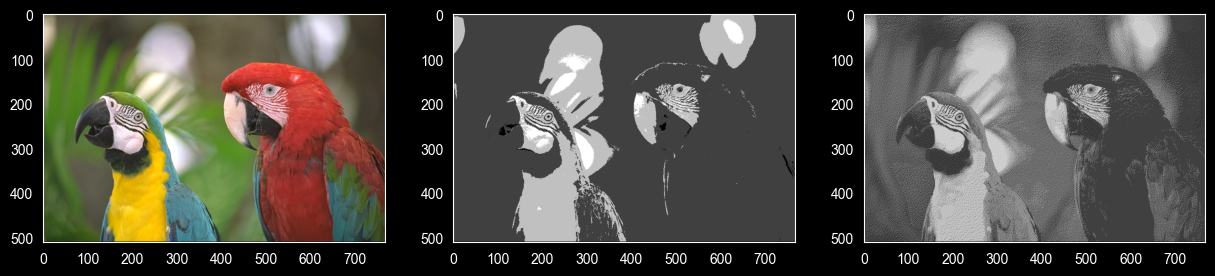

In [30]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(131), plt.imshow(img_orig), plt.grid(False)  # original image
plt.subplot(132), plt.imshow(quantized), plt.grid(False) # optimally quantized
plt.subplot(133), plt.imshow(dithered_img), plt.grid(False) # dithering

In [31]:
# Compute average quantization error for dithered image
img_dither = dithered_img.astype(np.float32)
avg_dith_error = np.mean(np.abs(img_orig - img_dither))
print('MAE:', avg_dith_error)

MAE: 43.348164


In [26]:
images = [
    ("Original",  img_orig),
    ("Quantized", quantized),
    ("Dithered",  dithered_img),
]

for name, img in images:
    # memory info
    bytes_used = img.nbytes
    kb_used = bytes_used / 1024.0
    print(f"{name}: {kb_used:.2f} KB (shape={img.shape}, dtype={img.dtype})")

    # ensure uint8
    img_to_save = img
    if img_to_save.dtype != np.uint8:
        img_to_save = np.clip(img_to_save, 0, 255).astype(np.uint8)

    # If your images are in RGB (as used by matplotlib), convert to BGR for OpenCV
    if img_to_save.ndim == 3 and img_to_save.shape[2] == 3:
        img_to_save_bgr = cv2.cvtColor(img_to_save, cv2.COLOR_RGB2BGR)
    else:
        img_to_save_bgr = img_to_save

    # add an extension, e.g. PNG
    filename = f"{name}.png"   # or .jpg if you prefer

    ok = cv2.imwrite(filename, img_to_save_bgr)
    if not ok:
        print(f"Failed to save {name} to {filename}")
    else:
        print(f"Saved {name} as {filename}")

Original: 1152.00 KB (shape=(512, 768, 3), dtype=uint8)
Saved Original as Original.png
Quantized: 1152.00 KB (shape=(512, 768, 3), dtype=uint8)
Saved Quantized as Quantized.png
Dithered: 1152.00 KB (shape=(512, 768, 3), dtype=uint8)
Saved Dithered as Dithered.png


### Questions
* Which image has higher quantization error? Optimally quantized or dithered?
* Which image looks better to you?
* Can you repeat the same process using only two colours: black and white? Show me :-)

### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

## Base method:
- Fixed K

In [32]:
# Build palette (your existing code, slightly cleaned)
data = np.reshape(img, (-1, 3)) #                                         data preparation for k-means
k = 16 #                                                                  fixed number of clusters
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(data) # Apply k-means to find the optimal color palette
palette = kmeans.cluster_centers_.astype(np.float32) #                    Extract the optimal colors


# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = img.astype(np.float32).copy()      # <-- IMPORTANT: float32
dithering = np.zeros_like(img, dtype=np.uint8)

rows, cols = img.shape[:2]

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value (already includes diffused error)
        pixel = img_tmp[r, c, :]  # float32, shape (3,)

        # Find the closest color from the palette (Euclidean distance)
        distance = palette - pixel                 # (K, 3)
        idx = np.argmin(np.sum(distance * distance, axis=1))
        new_pixel = palette[idx]                   # float32, (3,)

        # Compute quantization error
        quant_error = pixel - new_pixel            # float32, (3,)

        # Diffuse the quantization error according to the FS diffusion matrix
        img_tmp[r,     c + 1, :] += quant_error * (7.0 / 16.0)
        img_tmp[r + 1, c - 1, :] += quant_error * (3.0 / 16.0)
        img_tmp[r + 1, c,     :] += quant_error * (5.0 / 16.0)
        img_tmp[r + 1, c + 1, :] += quant_error * (1.0 / 16.0)

        # Keep values in valid range (prevents runaway/black artifacts)
        img_tmp[r,     c + 1, :] = np.clip(img_tmp[r,     c + 1, :], 0.0, 255.0)
        img_tmp[r + 1, c - 1, :] = np.clip(img_tmp[r + 1, c - 1, :], 0.0, 255.0)
        img_tmp[r + 1, c,     :] = np.clip(img_tmp[r + 1, c,     :], 0.0, 255.0)
        img_tmp[r + 1, c + 1, :] = np.clip(img_tmp[r + 1, c + 1, :], 0.0, 255.0)

        # Apply dithering (write quantized color)
        dithering[r, c, :] = np.clip(new_pixel, 0.0, 255.0).astype(np.uint8)

C:\Users\username\Projects\Computer-Vision-v2\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (16). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


(<Axes: >, <matplotlib.image.AxesImage at 0x2d0eea22350>, None)

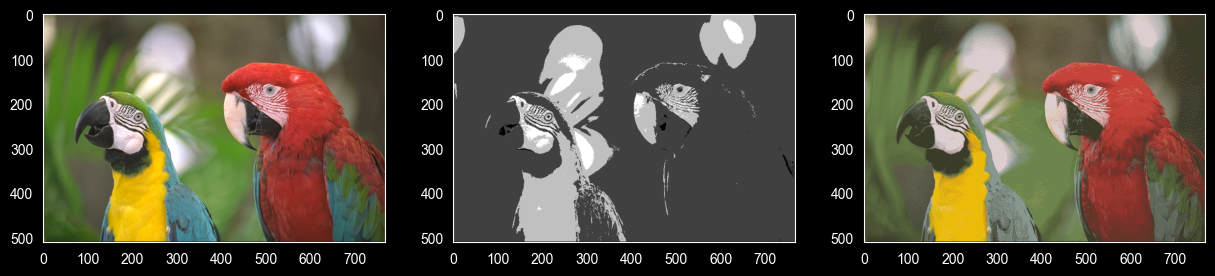

In [33]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(131), plt.imshow(img_orig), plt.grid(False)  # original image
plt.subplot(132), plt.imshow(quantized), plt.grid(False) # optimally quantized
plt.subplot(133), plt.imshow(dithering), plt.grid(False) # dithering

## Advanced method:
- search optimal K based on mathematics calculations

In [55]:
def find_optimal_score(min_k, inertia_values: list, silhouette_scores: list) -> tuple:
    wcss = inertia_values     # inertia values
    s_score = silhouette_scores  # silhouette
    k_values = range(min_k, len(wcss) + (min_k - 1))

    # Define points for the line connecting the first and last WCSS values
    x1, y1 = k_values[0], wcss[0]
    x2, y2 = k_values[-1], wcss[-1]

    # Calculate the distances from each point to the line (Euclidean Distance)
    distances = []
    for i, (x, y) in enumerate(zip(k_values, wcss), start=0):
        numerator = abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
        denominator = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
        distances.append(numerator / denominator)

    # Find the index of the maximum distance (elbow point)
    optimal_k_elbow = distances.index(max(distances)) + (min_k - 1)

    # Silhouette method
    optimal_k_silhouette = k_values[s_score.index(max(s_score))]

    return optimal_k_silhouette, optimal_k_elbow

def show_optimal_k(min_k, k_values, wcss, s_score, optimal_k, optimal_k_silhouette):
    fig, ax1 = plt.subplots()

    # WCSS plot (left Y-axis)
    sns.lineplot(x=k_values, y=wcss, ax=ax1, color='blue', label='WCSS', legend=False)
    ax1.scatter(k_values, wcss, color='blue')
    ax1.scatter(optimal_k,
                wcss[optimal_k - min_k],
                color='red',
                label='Optimal k (WCSS)',
                edgecolors='white',
                linewidths=3,
                s=200,
                alpha=1.0
                )
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('WCSS', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Silhouette score plot (right Y-axis)
    ax2 = ax1.twinx()
    sns.lineplot(x=k_values, y=s_score, ax=ax2, color='green', label='Silhouette Score', legend=False)
    ax2.scatter(k_values, s_score, color='green')
    ax2.scatter(
        optimal_k_silhouette,
        s_score[optimal_k_silhouette - min_k],
        color='orange',
        label='Optimal k (Silhouette)',
        edgecolors='white',
        linewidths=3,
        s=200,
        alpha=1.0
    )
    ax2.set_ylabel('Silhouette Score', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    plt.title(f"Elbow vs Silhouette score (Optimal k: {optimal_k}, Silhouette Optimal k: {optimal_k_silhouette})")
    fig.tight_layout()
    fig.subplots_adjust(right=0.85)

    # Combine legends from both axes and use ax1.legend with loc='best'
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax1.legend(handles, labels, loc='center right')

    ax1.grid(False)
    ax2.grid(False)
    plt.grid(False)
    plt.figure(figsize=(12, 8))

In [49]:
# let's find optimum K for k-means
silhouette_scores = []
wcss = []

k_min = 2
k_max = 10

k_range = range(k_min, k_max + 1) # can be replaced with range by min and max num of clusters
sample_size = min(10000, len(data))

In [59]:
data = np.reshape(img, (-1, 3)) #                                         data preparation for k-means

def compute_for_k(k, data):

    data = data.astype(np.float32)

    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=0)
    kmeans.fit(data)
    inertia = kmeans.inertia_
    sil = silhouette_score(data, kmeans.labels_, sample_size=sample_size)
    return k, inertia, sil

results = Parallel(n_jobs=-1, verbose=1)(delayed(compute_for_k)(k, data) for k in k_range)

results.sort(key=lambda r: r[0])

wcss = [r[1] for r in results]
silhouette_scores = [r[2] for r in results]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:   26.8s remaining:   33.5s
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:   31.9s finished


In [53]:
def compute_for_k(k, data):

    data = data.astype(np.float32)

    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=0).fit(data)
    inertia = kmeans.inertia_
    sil = silhouette_score(data,
                           kmeans.labels_,
                           sample_size=sample_size
                           )
    return k, inertia, sil

results = {}
max_workers = os.cpu_count() * 2

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(compute_for_k, k, data): k for k in k_range}
    for i, future in enumerate(as_completed(futures), start=1):
        k, inertia, sil = future.result()
        results[k] = (inertia, sil)
        percentage = np.round(i / len(k_range) *100,1)
        print(f"Progress: {i} / {len(k_range)} [{percentage} %]")

wcss = [results[k][0] for k in k_range]
silhouette_scores = [results[k][1] for k in k_range]

C:\Users\username\Projects\Computer-Vision-v2\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Progress: 1 / 9 [11.1 %]
Progress: 2 / 9 [22.2 %]
Progress: 3 / 9 [33.3 %]
Progress: 4 / 9 [44.4 %]
Progress: 5 / 9 [55.6 %]
Progress: 6 / 9 [66.7 %]
Progress: 7 / 9 [77.8 %]
Progress: 8 / 9 [88.9 %]
Progress: 9 / 9 [100.0 %]


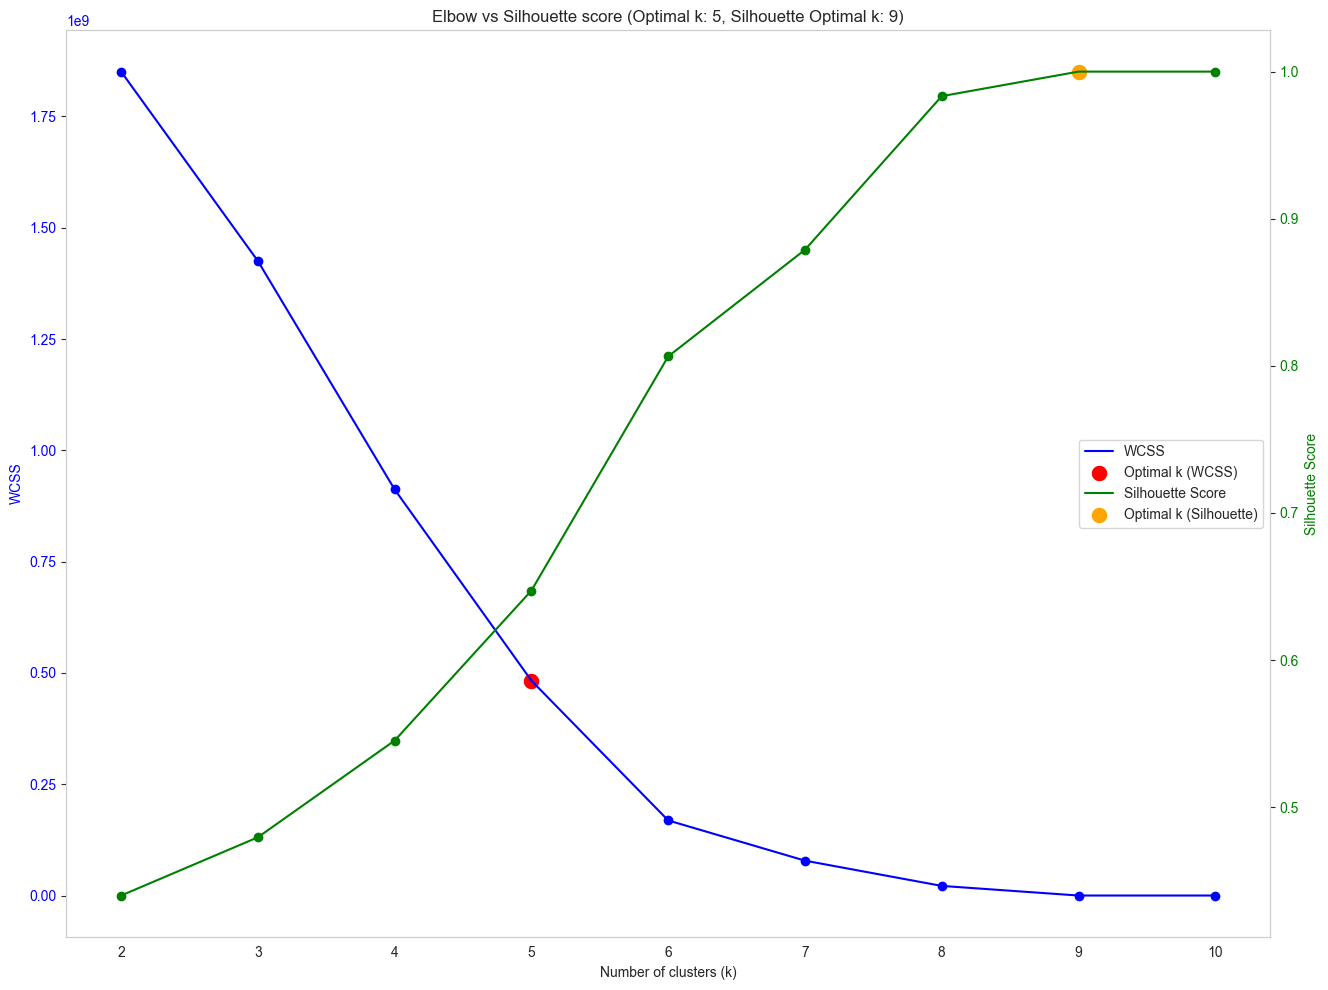

In [56]:
sns.set_style('whitegrid')

optimal_k_silhouette, optimal_k_elbow = find_optimal_score(min_k=k_min,
                                                           inertia_values=wcss,
                                                           silhouette_scores=silhouette_scores)
show_optimal_k(min_k=k_min,
               k_values=k_range,
               wcss=wcss,
               s_score=silhouette_scores,
               optimal_k=optimal_k_elbow,
               optimal_k_silhouette=optimal_k_silhouette)


(<Axes: >, <matplotlib.image.AxesImage at 0x2d0ef736c10>, None)

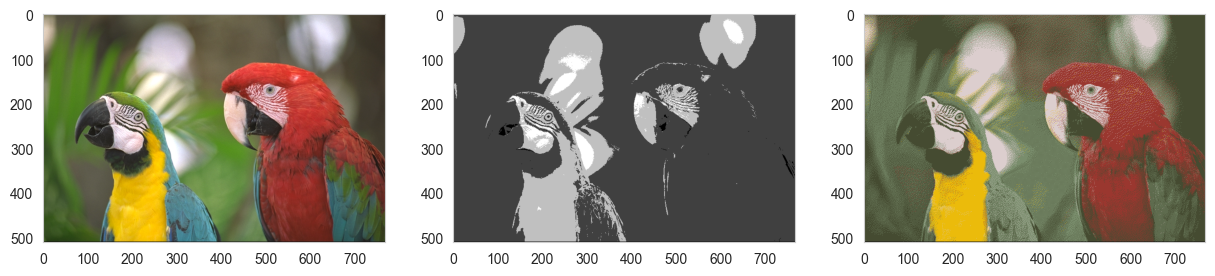

In [57]:
# Build palette (your existing code, slightly cleaned)
data = np.reshape(img, (-1, 3)) #                                         data preparation for k-means
k = optimal_k_elbow #                                                     fixed number of clusters ( use K-elbow method )
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(data) # Apply k-means to find the optimal color palette
palette = kmeans.cluster_centers_.astype(np.float32) #                    Extract the optimal colors


# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = img.astype(np.float32).copy()      # <-- IMPORTANT: float32
dithering = np.zeros_like(img, dtype=np.uint8)

rows, cols = img.shape[:2]

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value (already includes diffused error)
        pixel = img_tmp[r, c, :]  # float32, shape (3,)

        # Find the closest color from the palette (Euclidean distance)
        distance = palette - pixel                 # (K, 3)
        idx = np.argmin(np.sum(distance * distance, axis=1))
        new_pixel = palette[idx]                   # float32, (3,)

        # Compute quantization error
        quant_error = pixel - new_pixel            # float32, (3,)

        # Diffuse the quantization error according to the FS diffusion matrix
        img_tmp[r,     c + 1, :] += quant_error * (7.0 / 16.0)
        img_tmp[r + 1, c - 1, :] += quant_error * (3.0 / 16.0)
        img_tmp[r + 1, c,     :] += quant_error * (5.0 / 16.0)
        img_tmp[r + 1, c + 1, :] += quant_error * (1.0 / 16.0)

        # Keep values in valid range (prevents runaway/black artifacts)
        img_tmp[r,     c + 1, :] = np.clip(img_tmp[r,     c + 1, :], 0.0, 255.0)
        img_tmp[r + 1, c - 1, :] = np.clip(img_tmp[r + 1, c - 1, :], 0.0, 255.0)
        img_tmp[r + 1, c,     :] = np.clip(img_tmp[r + 1, c,     :], 0.0, 255.0)
        img_tmp[r + 1, c + 1, :] = np.clip(img_tmp[r + 1, c + 1, :], 0.0, 255.0)

        # Apply dithering (write quantized color)
        dithering[r, c, :] = np.clip(new_pixel, 0.0, 255.0).astype(np.uint8)

# Show quantized image (don't forget to cast back to uint8)
plt.subplot(131), plt.imshow(img_orig), plt.grid(False)  # original image
plt.subplot(132), plt.imshow(quantized), plt.grid(False) # optimally quantized
plt.subplot(133), plt.imshow(dithering), plt.grid(False) # dithering

(<Axes: >, <matplotlib.image.AxesImage at 0x2d0ef49ccd0>, None)

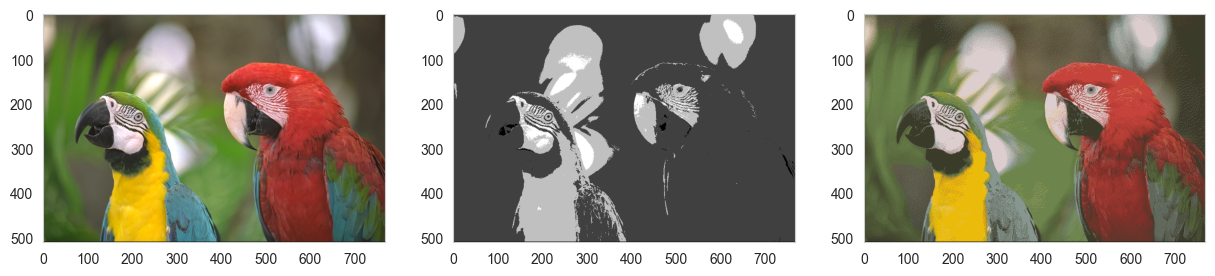

In [58]:
# Build palette (your existing code, slightly cleaned)
data = np.reshape(img, (-1, 3)) #                                         data preparation for k-means
k = optimal_k_silhouette #                                                fixed number of clusters ( using optimal Silhouette score )
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(data) # Apply k-means to find the optimal color palette
palette = kmeans.cluster_centers_.astype(np.float32) #                    Extract the optimal colors


# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = img.astype(np.float32).copy()      # <-- IMPORTANT: float32
dithering = np.zeros_like(img, dtype=np.uint8)

rows, cols = img.shape[:2]

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value (already includes diffused error)
        pixel = img_tmp[r, c, :]  # float32, shape (3,)

        # Find the closest color from the palette (Euclidean distance)
        distance = palette - pixel                 # (K, 3)
        idx = np.argmin(np.sum(distance * distance, axis=1))
        new_pixel = palette[idx]                   # float32, (3,)

        # Compute quantization error
        quant_error = pixel - new_pixel            # float32, (3,)

        # Diffuse the quantization error according to the FS diffusion matrix
        img_tmp[r,     c + 1, :] += quant_error * (7.0 / 16.0)
        img_tmp[r + 1, c - 1, :] += quant_error * (3.0 / 16.0)
        img_tmp[r + 1, c,     :] += quant_error * (5.0 / 16.0)
        img_tmp[r + 1, c + 1, :] += quant_error * (1.0 / 16.0)

        # Keep values in valid range (prevents runaway/black artifacts)
        img_tmp[r,     c + 1, :] = np.clip(img_tmp[r,     c + 1, :], 0.0, 255.0)
        img_tmp[r + 1, c - 1, :] = np.clip(img_tmp[r + 1, c - 1, :], 0.0, 255.0)
        img_tmp[r + 1, c,     :] = np.clip(img_tmp[r + 1, c,     :], 0.0, 255.0)
        img_tmp[r + 1, c + 1, :] = np.clip(img_tmp[r + 1, c + 1, :], 0.0, 255.0)

        # Apply dithering (write quantized color)
        dithering[r, c, :] = np.clip(new_pixel, 0.0, 255.0).astype(np.uint8)

# Show quantized image (don't forget to cast back to uint8)
plt.subplot(131), plt.imshow(img_orig), plt.grid(False)  # original image
plt.subplot(132), plt.imshow(quantized), plt.grid(False) # optimally quantized
plt.subplot(133), plt.imshow(dithering), plt.grid(False) # dithering

(<matplotlib.image.AxesImage at 0x26cd54a6c10>, None)

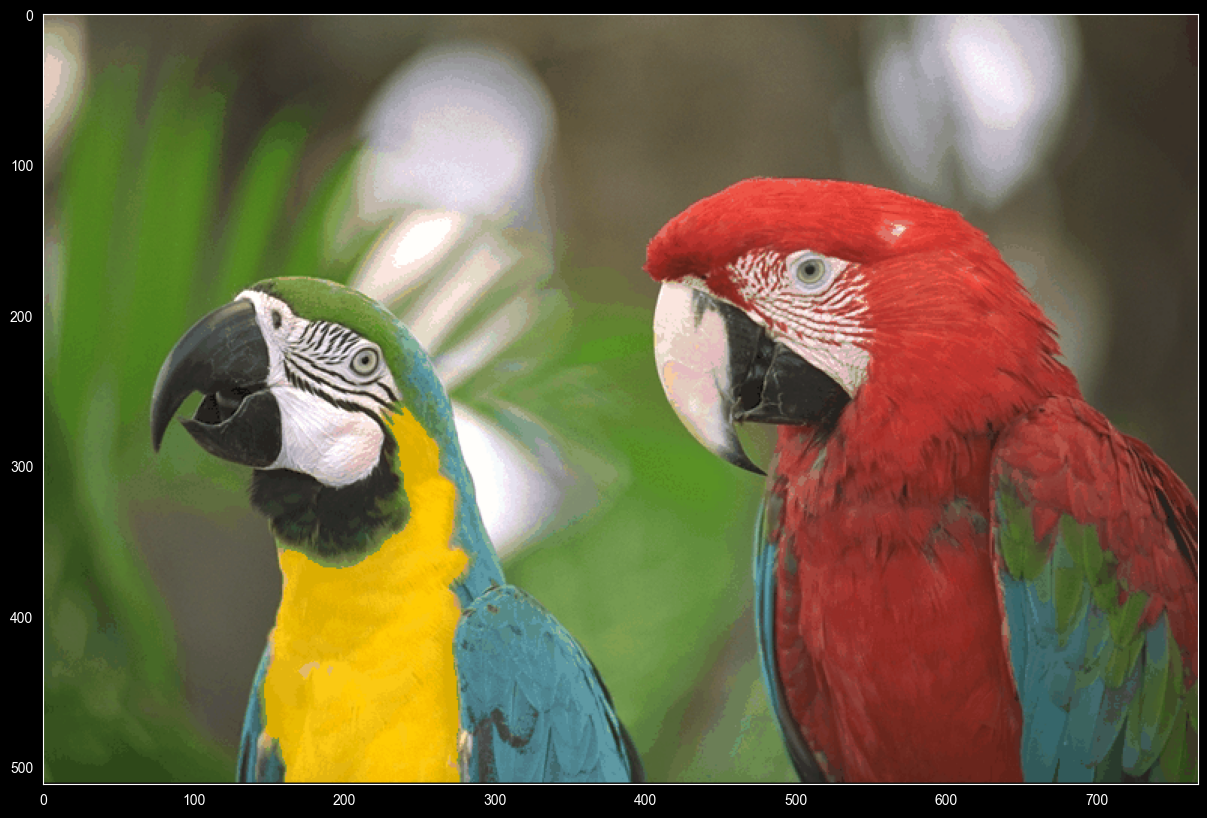

In [7]:
# Floyd–Steinberg color dithering via palette quantization using Pillow implementation much faster (1s vs 45s through NumPy iteration loop )
from PIL import Image

pil_img = Image.fromarray(img_orig)

dithered = pil_img.quantize(
    colors=256,                      # target palette size
    method=Image.MEDIANCUT,          # or Image.FASTOCTREE
    dither=Image.FLOYDSTEINBERG
)

# Optional: convert back to RGB
dithered_rgb = dithered.convert("RGB")

plt.imshow(dithered_rgb), plt.grid(False)


### Bonus (use implemented kmeans in cv2 )

In [19]:
# Build (N, features) float32 data
if img.ndim == 2:  # grayscale -> feature is intensity
    data = img.reshape((-1, 1)).astype(np.float32)
else:  # color -> features are B, G, R
    data = img.reshape((-1, 3)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
flags = cv2.KMEANS_RANDOM_CENTERS

K=32 # max colors

compactness, labels, centers = cv2.kmeans(
    data=data,
    K=K,
    bestLabels=None,
    criteria=criteria,
    attempts=10,
    flags=flags,
)

center = np.uint8(centers)
flat_centers = center[labels.flatten()]
quantized_img = flat_centers.reshape(img.shape)

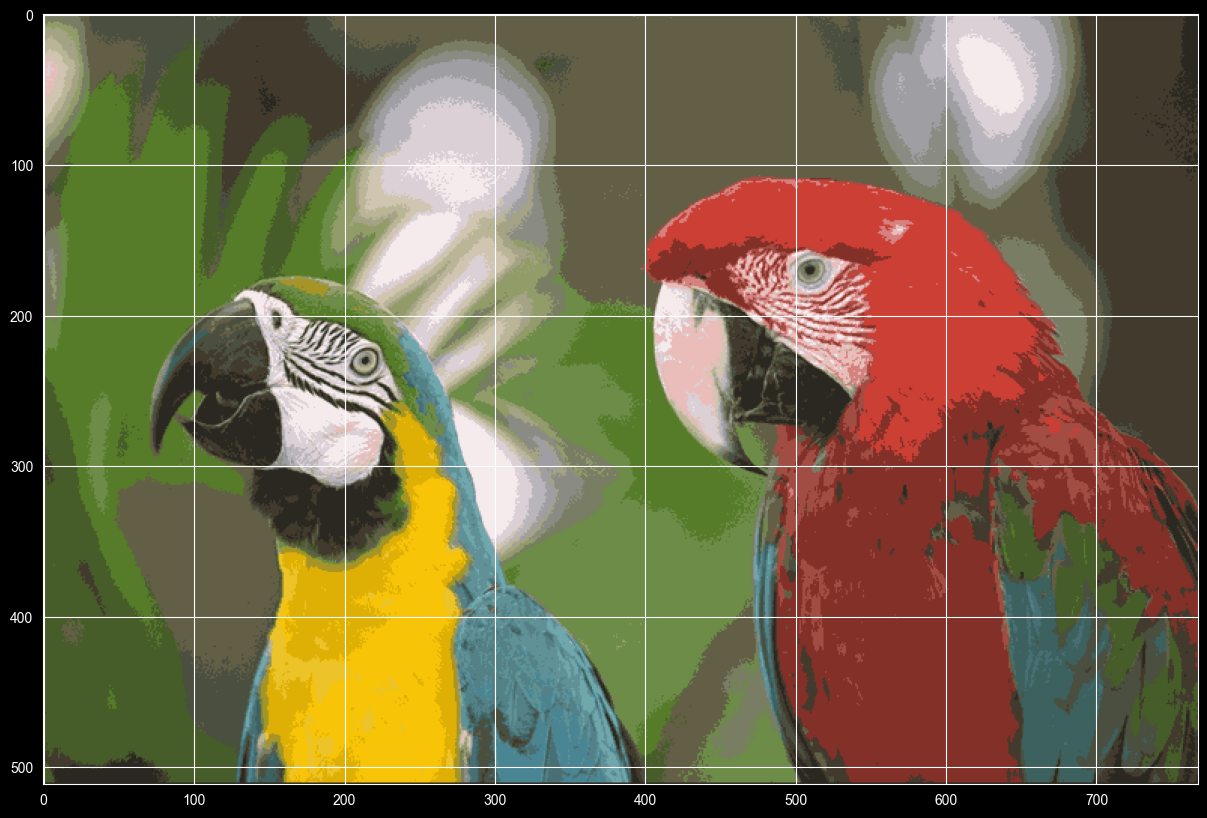

In [20]:
plt.imshow(quantized_img)

Apply FS dithering the same way you did before.
* Q: How does the result look like to you?
* A: The FS dithering result looks visually smoother, with reduced banding but a noticeable grain/noise pattern across flat areas.
* Q: What happens if we use 32 colors?
* A: With32 colors, the image looks more posterized and the dithering noise is more pronounced to hide banding
* Q: And what happens if we use 256 colors?
* A: With 256 colors, the image is much closer to the original, with minimal banding